# **Analyis of Reports in the City of Zurich**

The primary objective of this analysis is to examine the **Züri wie neu** dataset to identify both spatial and temporal patterns. To achieve this, I will employ various visualization techniques. Additionally, a secondary dataset featuring waste container locations will be integrated to investigate whether their distribution influences the frequency of waste-related ('Abfall/Sammelstelle') reports across different districts.

In [31]:
import geopandas as gpd
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Load the Data and Geospatial Data Preperation

In [36]:
# Load the quartiere polygons
quartiere_gdf = gpd.read_file("../data/raw/Zurich_quarters.gpkg") # ".." to get on level up in folder structure

# Load the lakes
lakes_gdf = gpd.read_file("../data/processed/zurichsee.gpkg")
lakes_gdf = lakes_gdf.to_crs(epsg=2056)

# Load the cleaned reports
reports_df = pd.read_csv("../data/processed/reports_cleaned.csv")
reports_gdf = gpd.GeoDataFrame(reports_df, geometry=gpd.points_from_xy(reports_df.e, reports_df.n, crs="EPSG:2056"))

# Calculate the area in km² of the districts for standardisation and ensure consistent CRS
quartiere_gdf = quartiere_gdf.to_crs(epsg=2056).copy()
quartiere_gdf["area_km2"] = quartiere_gdf.geometry.area / 1_000_000

# Spatial Join: assign each report to a district
reports_gdf = reports_gdf.to_crs(epsg=2056)
# Extract the year from the ‘date’ column
reports_gdf["date"] = pd.to_datetime(reports_gdf["date"])
reports_gdf["year"] = reports_gdf["date"].dt.year

reports_quartiere_gdf = gpd.sjoin(reports_gdf, quartiere_gdf, how="inner", predicate="within")

# Aggregate number of reports per district
report_counts = reports_quartiere_gdf.groupby("name").size().reset_index(name="count")

# Merge aggregated counts back to district geometries
quartiere_counts_gdf = quartiere_gdf.merge(report_counts, on="name", how="left")

# Handle missing values and compute report denisty per km2
quartiere_counts_gdf["count"] = quartiere_counts_gdf["count"].fillna(0)
quartiere_counts_gdf["density"] = quartiere_counts_gdf["count"] / quartiere_counts_gdf["area_km2"]

## ***Which neighbourhoods receive the highest number of reports?***

Examining the three maps  and the histogram below reveals that the Aussersihl district recorded the highest density of reports between 2016 and 2025, exceeding 3000 reports per km². This is followed by the Altstadt with approximately 2500 per km². A general pattern is evident: neighborhoods closer to the city center show significantly more reports than those located further out. This trend is likely due to the concentration of businesses, restaurants, and nightlife in the city center, resulting in a higher volume of reports compared to the quieter residential areas on the outskirts.

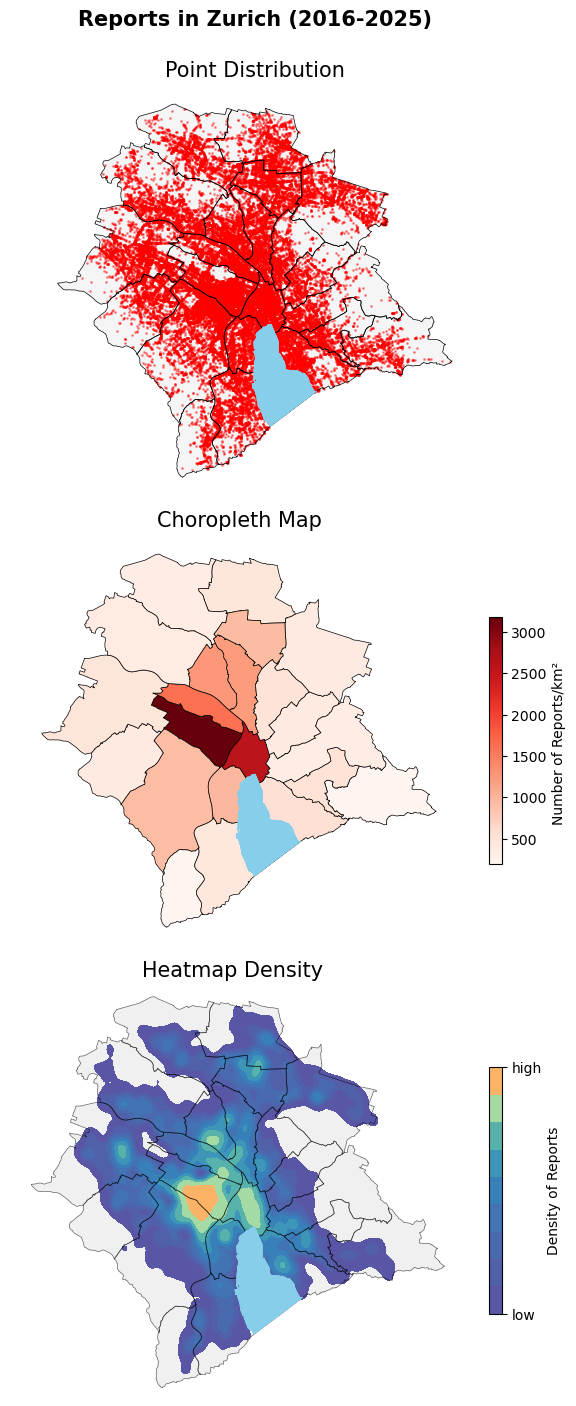

In [42]:
# Plots showing the distribution of reports (2016-2025)
# 1. Point distribution
fig, axs = plt.subplots(3, 1, figsize=(7,14))
fig.suptitle("Reports in Zurich (2016-2025)", fontsize=15, x=0.5, y= 1.001, fontweight="bold")

quartiere_gdf.plot(ax=axs[0], color="whitesmoke", linewidth= 0.5, zorder=1)
reports_gdf.plot(ax=axs[0], color= "red", markersize=1, alpha=0.4, zorder=2)
lakes_gdf.plot(ax=axs[0], color = "skyblue", zorder=4)
quartiere_gdf.boundary.plot(ax=axs[0], color="black", linewidth=0.5, zorder=3)

axs[0].axis("off")
axs[0].set_title("Point Distribution", fontsize=15)

# 2. Choropleth Map
quartiere_counts_gdf = quartiere_gdf.merge(report_counts, on="name", how="left")

lakes_gdf.plot(ax=axs[1], color="skyblue",zorder=2)

quartiere_counts_gdf.plot(
    column="density",         
    cmap="Reds",             
    legend=True,              
    legend_kwds={'label': "Number of Reports/km² ", "orientation": "vertical", "shrink": 0.6},
    edgecolor="black",          
    linewidth=0.5,
    ax=axs[1],
    zorder=1)

axs[1].set_title("Choropleth Map", fontsize=15)
axs[1].axis("off")

# 3. Heatmap (Kernel Density Estimate)
quartiere_gdf.plot(ax=axs[2], color="#f0f0f0", edgecolor="none")

sns.kdeplot(
    x=reports_gdf.e, y=reports_gdf.n, 
    ax=axs[2], 
    cmap="Spectral_r", 
    fill=True, 
    thresh=0.05, # the threshold at which the heatmap is displayed (> 5% of the maximum value)
    cbar=True,             
    cbar_kws={"label": "Density of Reports", "orientation": "vertical", "shrink": 0.6},
    bw_adjust=0.5)  # Influences smoothness of heat map

# Adjust scale of color bar
cbar = axs[2].collections[-1].colorbar

vmin, vmax = cbar.ax.get_ylim()
cbar.set_ticks([vmin, vmax])

# Replace numbers with text
cbar.set_ticklabels(["low", "high"])

lakes_gdf.plot(ax=axs[2], color = "skyblue", zorder= 2)
quartiere_gdf.boundary.plot(ax=axs[2], color="black", linewidth=0.5, alpha=0.6, zorder=1) # only the boundaries

axs[2].axis("off")
axs[2].set_title("Heatmap Density", fontsize=15)

plt.tight_layout()
plt.savefig("../outputs/reports_distribution.png", dpi=300, bbox_inches="tight") 
plt.show()

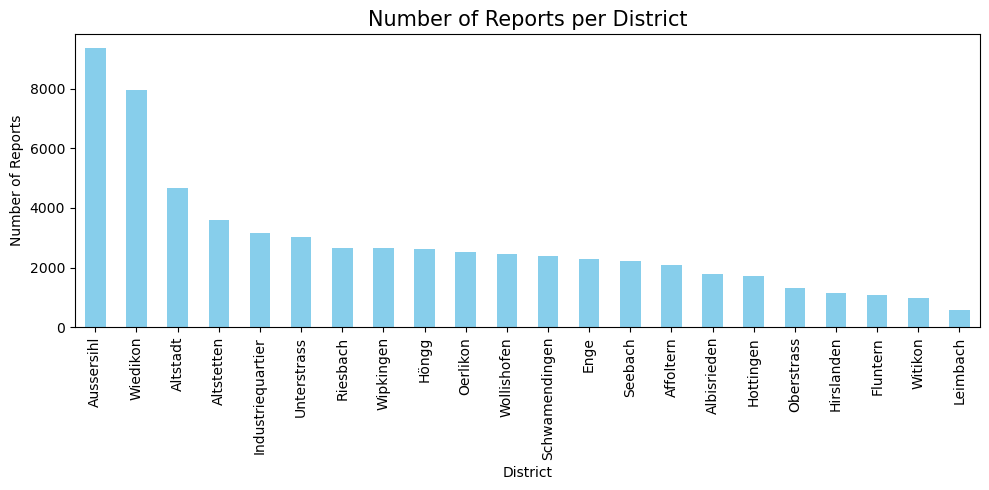

In [34]:
# Historam of number of reports per district
fig, ax = plt.subplots(figsize=(10,5))

reports_quartiere_gdf["name"].value_counts().plot(kind="bar", ax=ax, color="skyblue")

ax.set_title("Number of Reports per District", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("District")

plt.tight_layout()
plt.savefig("../outputs/reports_per_district.png", dpi=300, bbox_inches="tight")
plt.show()

## ***How does the number of reports vary over time or between neighbourhoods?***

The provided series of choropleth maps and the histogram illustrates the evolution of reporting density (reports per km²) across Zurich's districts over a ten-year period. The data reveals two primary trends: a significant temporal increase in total reports and a persistent geographical concentration in the city center.

There is a striking upward trend in the number of reports over the decade. In the early years (2016–2018), the maps appear relatively pale, indicating a low reporting density across most districts. However, starting in 2019, the color intensity increases significantly. By 2024, the density in the most active areas has more than doubled compared to 2016, reaching peaks of over 600 reports per km². The fact that 2025 already shows such high values suggests that the frequency of reporting is continuing to accelerate.

Despite the overall increase in volume, the spatial distribution remains remarkably consistent. The "hotspots" are invariably located in the central districts, particularly in Aussersihl (District 4) and the Altstadt (District 1). These areas consistently show the highest density, represented by the deep red shades. In contrast, the peripheral and more residential districts (such as Witikon, Höngg, or Affoltern) remain light-colored throughout the entire period, indicating that the challenges being reported are predominantly an urban-center phenomenon.

This overall increas in the numer of reports might be a result of several factors:
- The rising popularity of mobile reporting due to the digitalisation makes it easier for citizens to report infrastructure issues, waste, or maintenance needs.
-  As the city center become more densely used for work, nightlife, and tourism, the likelihood of reportable incidents (e.g., littering, noise, or damage) increased.
- A growing sense of civic responsibility and higher expectations regarding urban cleanliness and maintenance likely contribute to the surge in data points.

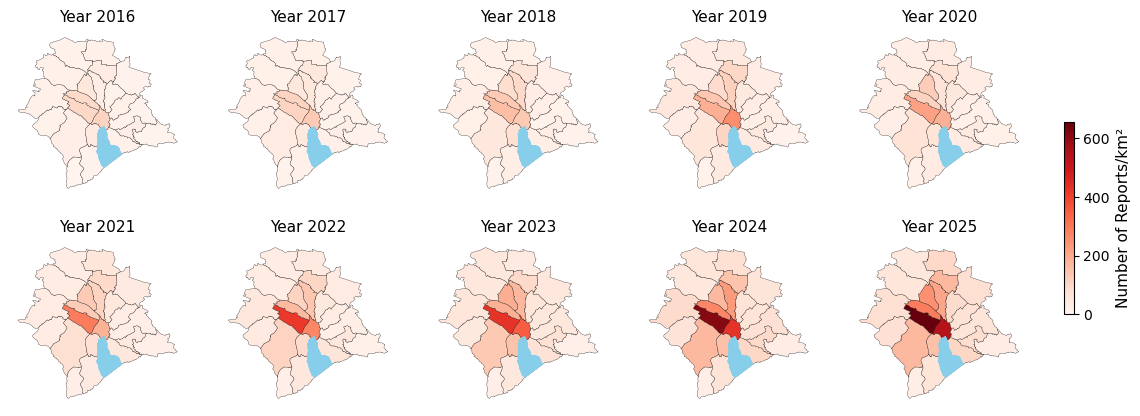

In [37]:
# Group by year and calculate the number of reports
yearly_counts = reports_quartiere_gdf.groupby(["year", "name"]).size().reset_index(name="count")

# Standardisation
yearly_density = yearly_counts.merge(quartiere_gdf[["name", "area_km2"]], on="name")
yearly_density["density"] = yearly_density["count"] / yearly_density["area_km2"]
max_yearly_density = yearly_density["density"].max()

# Create choropleth maps
fig, axs = plt.subplots(2,5, figsize=(16,5))
axs = axs.flatten()

jahre = range(2016, 2026)

for i, jahr in enumerate(jahre):
    ax = axs[i]
    counts_jahr = yearly_counts[yearly_counts["year"] == jahr]
    show = quartiere_gdf.merge(counts_jahr, on="name", how="left")

    show["density"] = show["count"] / show["area_km2"]
    
    show.plot(column="density", cmap="Reds", vmin=0, vmax=max_yearly_density, 
                  edgecolor="black", linewidth=0.2, ax=ax)
    lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)
    
    ax.set_title(f"Year {jahr}", fontsize=11)
    ax.axis("off")

sm = plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=0, vmax=max_yearly_density))
sm._A = [] 
cbar = fig.colorbar(sm, ax=axs, orientation="vertical", shrink=0.5, pad=0.03)
cbar.set_label("Number of Reports/km²", fontsize=11)

plt.savefig("../outputs/reports_yearly_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()


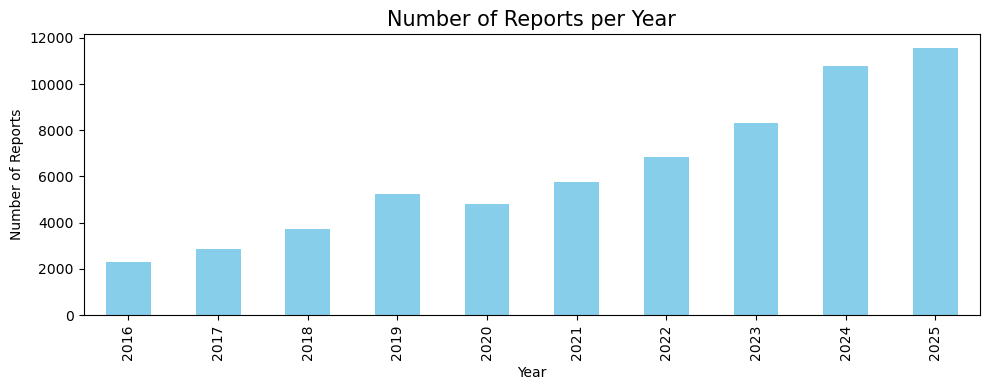

In [38]:
# Histogram of reports per year
fig, ax = plt.subplots(figsize=(10,4))

reports_gdf["year"].value_counts().sort_index().plot(kind="bar", ax=ax, color="skyblue")

ax.set_title("Number of Reports per Year", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig("../outputs/reports_per_year.png", dpi=300, bbox_inches="tight")
plt.show()

## ***Are certain types of issues concentrated in particular neighbourhoods?***

An examination of the histogram below reveals that the waste related reports is by far the most frequent reporting category, with nearly 25'000 reports recorded over the last ten years. Its spatial density distribution closely mirrors the overall reporting pattern. Aussersihl exhibits the highest concentration by a significant margin, exceeding 2'000 reports per km², followed by the surrounding districts. To determine whether this trend is linked to the availability of disposal infrastructure, the following section will analyze the distribution of waste containers in more detail.

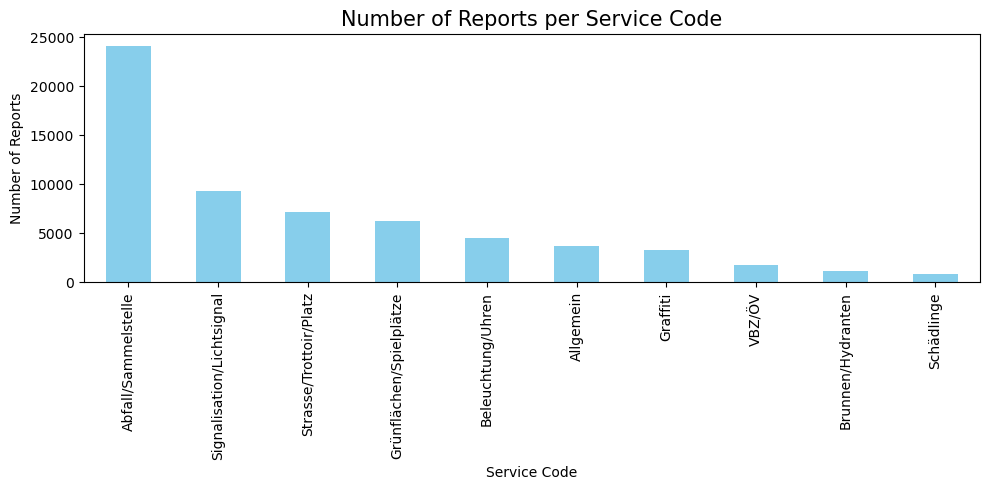

In [39]:
# Histogram of Number of Reports per Service Code
fig, ax = plt.subplots(figsize=(10,5))

reports_gdf["service_code"].value_counts().plot(kind='bar', ax=ax, color='skyblue')

ax.set_title("Number of Reports per Service Code", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("Service Code")

plt.tight_layout()
plt.savefig("../outputs/reports_per_service_code.png", dpi=300, bbox_inches='tight')
plt.show()

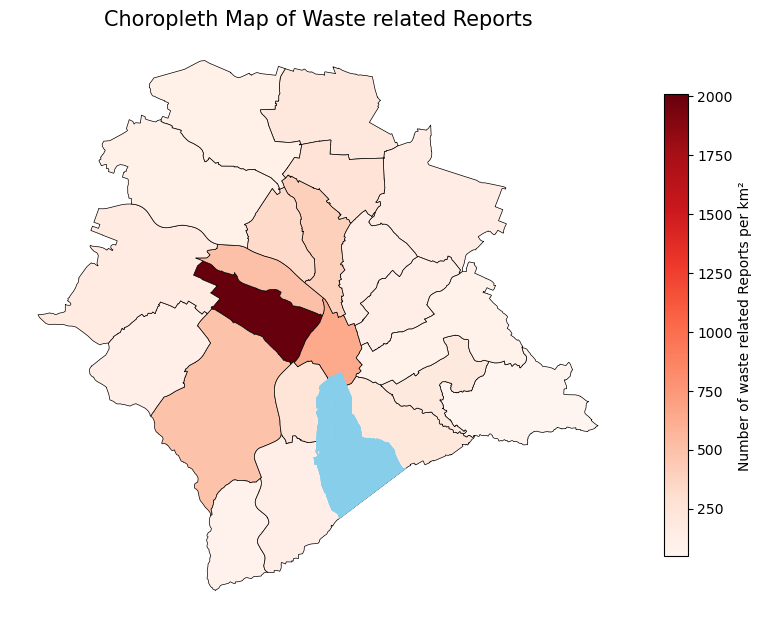

In [40]:
# Choropleth Map of waste related Reports
fig, ax = plt.subplots(figsize=(8,8))

# Filter waste-related reports (already spatially joined data)
abfall_reports_gdf = reports_quartiere_gdf[reports_quartiere_gdf["service_code"] == "Abfall/Sammelstelle"]

# Aggregate by district
abfall_counts = (abfall_reports_gdf.groupby("name").size().reset_index(name="count"))

# Merge with district geometries
quartiere_abfall_gdf = quartiere_gdf.merge(abfall_counts, on="name", how="left")

# Standardization
quartiere_abfall_gdf["count"] = quartiere_abfall_gdf["count"].fillna(0)
quartiere_abfall_gdf["density"] = quartiere_abfall_gdf["count"] / quartiere_abfall_gdf["area_km2"]

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)

quartiere_abfall_gdf.plot(
    column="density",
    cmap="Reds",
    legend=True,
    legend_kwds={
        "label": "Number of waste related Reports per km²",
        "orientation": "vertical",
        "shrink": 0.6},
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    zorder=1)

ax.set_title("Choropleth Map of Waste related Reports", fontsize=15)
ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/abfall_reports_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

## **Is there a correlation between waste containers and waste related reports?**

To investigate whether there is a relationship between waste container density and the density of waste related reports, a Pearson correlation test was conducted.

The test resulted in a correlation coefficient of `r = 0.4`, indicating a moderate positive correlation between the two variables. Districts with a higher density of waste containers therefore tend to also show a higher density of reports. 

The scatter plot supports this observation, as the data points generally show an upward trend. However, the relationship is not particularly strong and the data exhibits a considerable spread. In addition, several visible outliers influence the distribution, especially districts with exceptionally high report densities (Aussersihl) or very high container densities (Altstadt).

This suggests that, while container density may have some influence on the number of reports, additional factors are likely contributing to the observed reporting patterns.

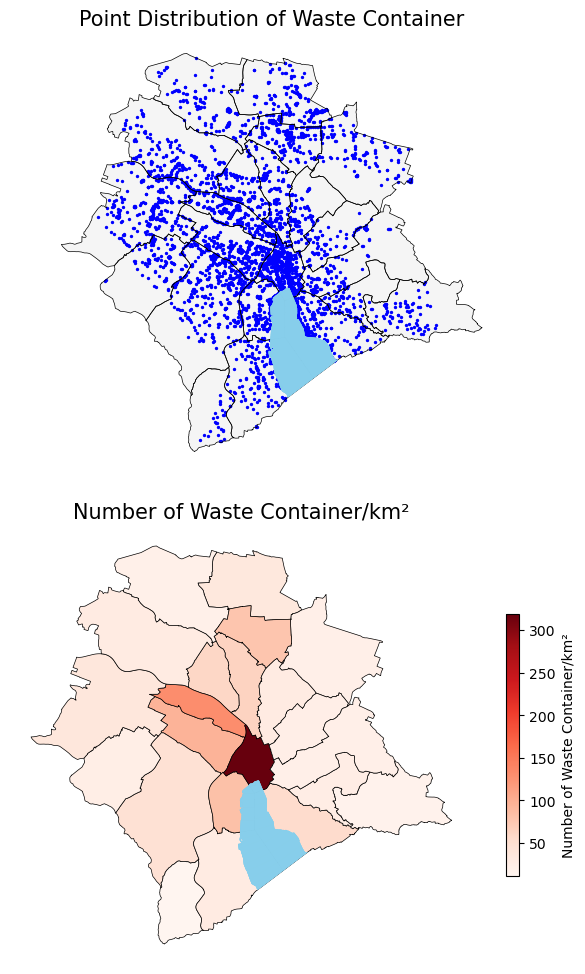

In [46]:
# Distribution of waste containers
abfallgefaesse = gpd.read_file("../data/raw/abfallgefaesse.gpkg")
abfallgefaesse = abfallgefaesse.to_crs(epsg=2056)

fig, axs = plt.subplots(2,1, figsize=(7, 10))

quartiere_gdf.plot(ax=axs[0], color="whitesmoke", linewidth=0.5, zorder=1)

abfallgefaesse.plot(
    ax=axs[0], 
    color="blue", 
    markersize=2,
    zorder=2, 
    label="Waste container")

lakes_gdf.plot(ax=axs[0], color="skyblue", zorder=4)

quartiere_gdf.boundary.plot(ax=axs[0], color="black", linewidth=0.5, zorder=3)

axs[0].axis("off")
axs[0].set_title("Point Distribution of Waste Container", fontsize =15)

# Choropleth Map
# Spatial Join
waste_quartiere_gdf = gpd.sjoin(abfallgefaesse, quartiere_gdf, how="inner", predicate="within")
waste_container_counts = waste_quartiere_gdf.groupby("name").size().reset_index(name="count")
quartiere_waste_container_counts_gdf = quartiere_gdf.merge(waste_container_counts, on="name", how="left")

# Standardization
quartiere_waste_container_counts_gdf["density"] = quartiere_waste_container_counts_gdf["count"] / quartiere_waste_container_counts_gdf["area_km2"]

lakes_gdf.plot(ax=axs[1], color="skyblue",zorder=2)

quartiere_waste_container_counts_gdf.plot(
    column="density",         
    cmap="Reds",             
    legend=True,              
    legend_kwds={'label': "Number of Waste Container/km²", 'orientation': "vertical", "shrink": 0.6},
    edgecolor="black",          
    linewidth=0.5,
    ax=axs[1],
    zorder=1)

axs[1].set_title("Number of Waste Container/km²", fontsize=15)
axs[1].axis("off")

plt.tight_layout()
plt.savefig("../outputs/dist_waste_container.png", dpi=300, bbox_inches="tight")
plt.show()

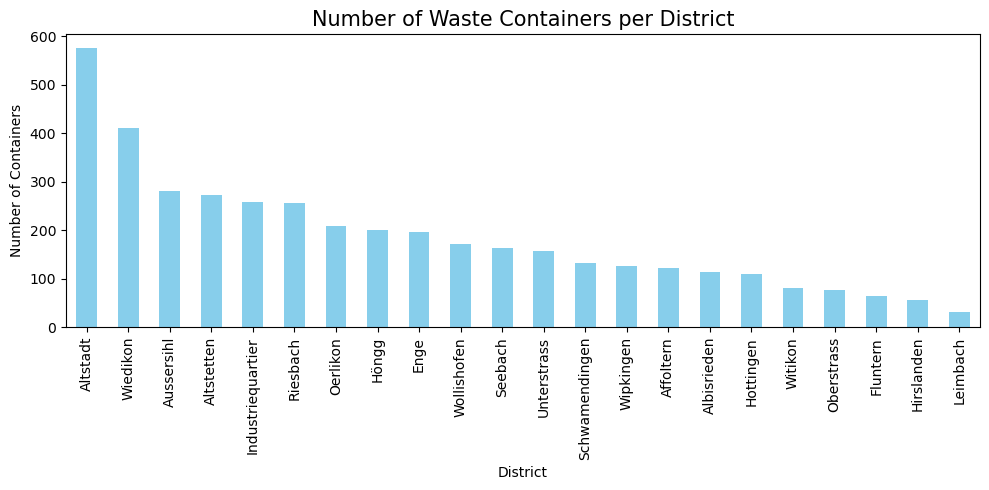

In [47]:
# Histogram of Waste Containers per District
waste_container_quartier = gpd.sjoin(abfallgefaesse, quartiere_gdf[['name', 'geometry']], how="inner", predicate="within")

waste_container_counts = waste_container_quartier.groupby("name").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

waste_container_counts.plot(
    kind="bar", 
    ax=ax, 
    color="skyblue")

ax.set_title("Number of Waste Containers per District", fontsize=15)
ax.set_ylabel("Number of Containers")
ax.set_xlabel("District")

plt.tight_layout()
plt.savefig("../outputs/waste_containers_per_district.png", dpi=300, bbox_inches="tight")
plt.show()

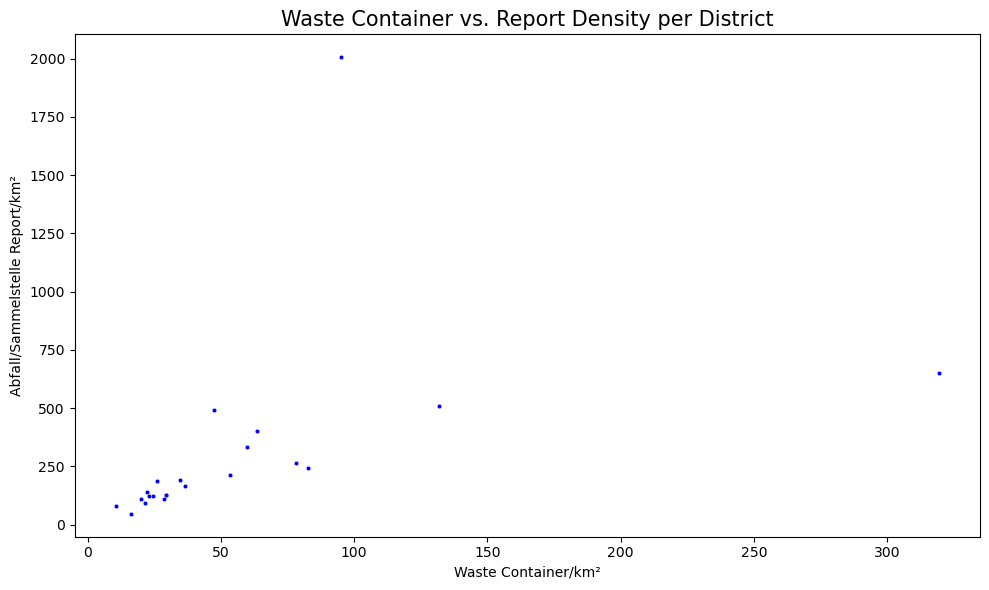

In [ ]:
# Scatterplot Waste Container vs. Report Density per District
df_container = quartiere_waste_container_counts_gdf[["name", "density"]].rename(columns={"density": "container_density"})
df_reports = quartiere_counts_gdf[["name", "density"]].rename(columns={"density": "report_density"})
analysis_df = df_container.merge(df_reports, on="name")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=analysis_df, 
    x="container_density", 
    y="report_density", 
    s=10,            
    color="blue")

plt.title("Waste Container vs. Report Density per District", fontsize=15)
plt.xlabel("Waste Container/km²")
plt.ylabel("Abfall/Sammelstelle Report/km²")

plt.tight_layout()

plt.savefig("../outputs/scatter_container_reports.png", dpi=300)
plt.show()

In [ ]:
correlation = analysis_df["container_density"].corr(analysis_df["report_density"])
print("Pearson-Korrelation:", correlation)

Pearson-Korrelation: 0.4311716279023768
